### Data Auditing ###

In [1]:
import pandas as pd

In [2]:
df= pd.read_csv(r"C:\Users\Abdulmalik\Downloads\ecommerce_retail_sales_10000_rows.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_ID        9788 non-null   object 
 1   Customer_Name   10000 non-null  object 
 2   Email           9530 non-null   object 
 3   Order_Date      10000 non-null  object 
 4   Product         9990 non-null   object 
 5   Category        10000 non-null  object 
 6   Region          10000 non-null  object 
 7   Quantity        9705 non-null   float64
 8   Unit_Price      10000 non-null  float64
 9   Revenue         10000 non-null  float64
 10  Discount        8329 non-null   float64
 11  Payment_Method  10000 non-null  object 
dtypes: float64(4), object(8)
memory usage: 937.6+ KB


In [3]:
df.isnull().sum()

Order_ID           212
Customer_Name        0
Email              470
Order_Date           0
Product             10
Category             0
Region               0
Quantity           295
Unit_Price           0
Revenue              0
Discount          1671
Payment_Method       0
dtype: int64

In [4]:
df.isna().sum()

Order_ID           212
Customer_Name        0
Email              470
Order_Date           0
Product             10
Category             0
Region               0
Quantity           295
Unit_Price           0
Revenue              0
Discount          1671
Payment_Method       0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

### Data Processing ###

In [6]:
df.dropna(subset=['Order_ID','Product'], inplace=True)

In [7]:
df['Customer_Name']=df['Customer_Name'].str.strip()
df['Product']=df['Product'].str.strip()
df['Region']=df['Region'].str.strip()

df['Category']=df['Category'].str.strip().str.lower()
df['Payment_Method']=df['Payment_Method'].str.strip().str.lower()

df['Order_Date']=pd.to_datetime(df['Order_Date'])

df['Quantity']=df['Quantity'].fillna(df['Revenue'] / df['Unit_Price']).astype(int)
df['Discount']=df['Discount'].fillna(0.0)
df['Email']=df['Email'].fillna('Unknown')
df.dtypes

Order_ID                  object
Customer_Name             object
Email                     object
Order_Date        datetime64[ns]
Product                   object
Category                  object
Region                    object
Quantity                   int64
Unit_Price               float64
Revenue                  float64
Discount                 float64
Payment_Method            object
dtype: object

In [8]:
df.isnull().sum()

Order_ID          0
Customer_Name     0
Email             0
Order_Date        0
Product           0
Category          0
Region            0
Quantity          0
Unit_Price        0
Revenue           0
Discount          0
Payment_Method    0
dtype: int64

In [9]:
df.dropna(subset=['Order_ID','Product'], inplace=True)

df.loc[:, 'Quantity'] = df['Quantity'].fillna(df['Revenue']/df['Unit_Price']).astype(int)
df.loc[:, 'Discount'] = df['Discount'].fillna(0.0)
df.loc[:, 'Email'] = df['Email'].fillna('Unknown')

print(df.isnull().sum())

Order_ID          0
Customer_Name     0
Email             0
Order_Date        0
Product           0
Category          0
Region            0
Quantity          0
Unit_Price        0
Revenue           0
Discount          0
Payment_Method    0
dtype: int64


                 Revenue  Quantity
Category                          
beauty       12990095.71     13259
books        13415049.33     13513
electronics  12521095.44     12578
fashion      12807758.18     12710
home         13540988.07     13202
sports       13583924.13     13500


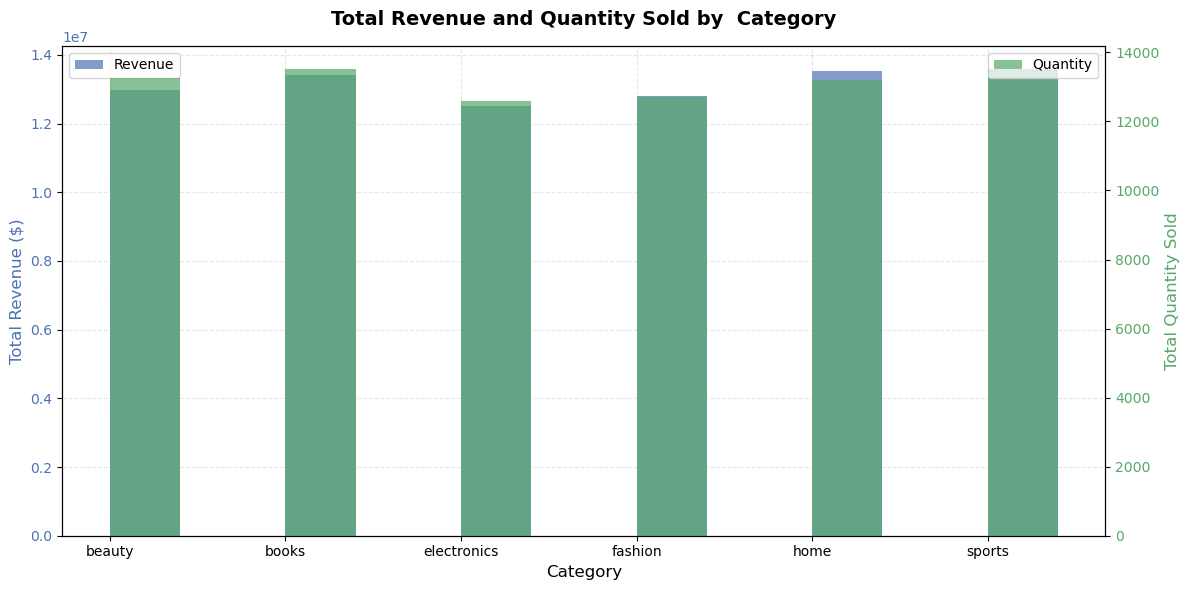

In [10]:
import matplotlib.pyplot as plt

category_analysis = df.groupby('Category')[['Revenue', 'Quantity']].sum()

print(category_analysis)
fig, ax1 = plt.subplots(figsize=(12,6))

color= '#4C72B0'
ax1.set_title('Total Revenue and Quantity Sold by  Category', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Category', fontsize=12)
ax1.set_ylabel('Total Revenue ($)', color=color , fontsize=12)
bars1 = ax1.bar(category_analysis.index, category_analysis['Revenue'], color=color, alpha=0.7, width=0.4,  align='edge', label='Revenue')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = '#55A868'
ax2.set_ylabel('Total Quantity Sold', color=color, fontsize=12)
bars2 = ax2.bar(category_analysis.index, category_analysis['Quantity'], color=color, alpha=0.7, width=0.4,  align='edge', label='Quantity')
ax2.tick_params(axis='y', labelcolor=color)

ax1.grid(True, linestyle='--', alpha=0.3)

fig.tight_layout()
ax1.legend(loc= 'upper left')
ax2.legend(loc= 'upper right')
plt.show()

In [11]:
Q1=df['Revenue'].quantile(0.25)
Q3=df['Revenue'].quantile(0.75)
IQR = Q3-Q1

upper_limit = Q3 = 1.5 * IQR
df_cleaned_final = df[df['Revenue'] <= upper_limit]

In [12]:
print(df_cleaned_final.shape)

(8002, 12)


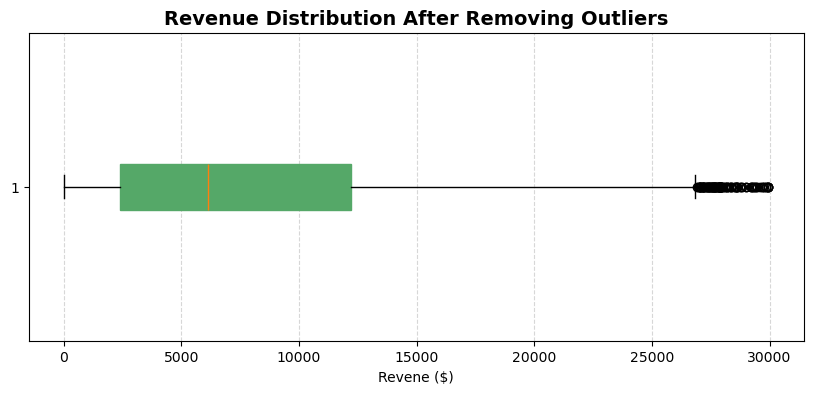

In [13]:
plt.figure(figsize=(10,4))
plt.boxplot(df['Revenue'], vert=False, patch_artist=True,
            boxprops=dict(facecolor='#55A868', color='#55A868'))
plt.title('Revenue Distribution After Removing Outliers', fontsize=14, fontweight='bold')
plt.xlabel('Revene ($)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

In [14]:
df.to_csv('ecommerce_sales_final_clean1.csv', index=False)